# Clinical Clustering Analysis

In [1]:
# Install required packages
!pip install -q scikit-learn scipy pandas matplotlib seaborn umap-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score,
    silhouette_samples
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from scipy.stats import kruskal, mannwhitneyu
import umap

In [3]:
# Load dataset
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "1" / "Features"
PATIENT_PROFILES_NAME = "patient_profiles.csv"

df = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

print(f"Dataset loaded: {df.shape[0]} patients, {df.shape[1]} features")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFeature columns:\n{df.columns.tolist()}")

Dataset loaded: 4278 patients, 49 features
Missing values: 0

Feature columns:
['subject_id', 'ct_complications_score', 'hemodynamic_instability_episodes', 'complex_patient', 'exam_abnormality_score', 'k_n', 'renal_function_category', 'high_risk_patient', 'hf_severity_first', 'cardiac_remodeling_score', 'metabolic_dysregulation', 'age_missing', 'oxygen_saturation', 'creat_deterioration', 'procedure_complexity', 'heart_rate', 'infection_severity_score_missing', 'temperature', 'readmission_count', 'testing_intensity', 'cad_severity_last_missing', 'gender_missing', 'k_min', 'hf_severity_last', 'age', 'gender', 'k_max', 'bp_systolic', 'total_procedures', 'cad_severity_score_missing', 'metabolic_complexity', 'disease_burden_score', 'total_engagement_days', 'ct_complications_score_missing', 'respiratory_rate', 'cad_severity_first', 'creat_delta', 'heart_failure_severity_score_missing', 'hf_severity_last_missing', 'cad_severity_last', 'hf_severity_first_missing', 'cad_severity_first_missing',

## Feature Organization

### Feature Groups

In [4]:
# Select features for clustering
features_for_clustering = df.copy().drop(columns=['subject_id'])
print(f"\nClustering dataset: {features_for_clustering.shape}")


Clustering dataset: (4278, 48)


## Data Preprocessing for Clustering

In [5]:
# Separate binary and continuous features for appropriate scaling
from sklearn.compose import ColumnTransformer

binary_cols = []
continuous_cols = []

for col in features_for_clustering.columns:
    unique_vals = features_for_clustering[col].nunique()
    if unique_vals <= 2:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"Binary features: {len(binary_cols)}")
print(binary_cols)
print(f"\nContinuous features: {len(continuous_cols)}")
print(continuous_cols)

Binary features: 12
['age_missing', 'creat_deterioration', 'infection_severity_score_missing', 'cad_severity_last_missing', 'gender_missing', 'gender', 'cad_severity_score_missing', 'ct_complications_score_missing', 'heart_failure_severity_score_missing', 'hf_severity_last_missing', 'hf_severity_first_missing', 'cad_severity_first_missing']

Continuous features: 36
['ct_complications_score', 'hemodynamic_instability_episodes', 'complex_patient', 'exam_abnormality_score', 'k_n', 'renal_function_category', 'high_risk_patient', 'hf_severity_first', 'cardiac_remodeling_score', 'metabolic_dysregulation', 'oxygen_saturation', 'procedure_complexity', 'heart_rate', 'temperature', 'readmission_count', 'testing_intensity', 'k_min', 'hf_severity_last', 'age', 'k_max', 'bp_systolic', 'total_procedures', 'metabolic_complexity', 'disease_burden_score', 'total_engagement_days', 'respiratory_rate', 'cad_severity_first', 'creat_delta', 'cad_severity_last', 'admission_count', 'cardiac_complexity', 'uniq

In [6]:
# Create preprocessing pipeline
# Binary: StandardScaler (to normalize 0/1 to similar scale as continuous)
# Continuous: RobustScaler (less sensitive to outliers)
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', 'passthrough', binary_cols),
        ('continuous', RobustScaler(), continuous_cols)
    ]
)

X_scaled = preprocessor.fit_transform(features_for_clustering)
X_scaled_df = pd.DataFrame(
    X_scaled, 
    columns=binary_cols + continuous_cols,
    index=features_for_clustering.index
)

print("\n✅ Data scaled successfully")
print(f"Scaled data shape: {X_scaled_df.shape}")
print(f"\nScaled data statistics:")
print(f"Mean (should be ~0 for continuous): {X_scaled[:, len(binary_cols):].mean(axis=0).mean():.4f}")
print(f"Std (should be ~1): {X_scaled.std(axis=0).mean():.4f}")


✅ Data scaled successfully
Scaled data shape: (4278, 48)

Scaled data statistics:
Mean (should be ~0 for continuous): 0.0493
Std (should be ~1): 0.8775


## Dimensionality Reduction for Visualization (PCA and UMAP)

PCA Variance Explained:
  PC1: 93.14%
  PC2: 1.29%
  Total: 94.43%


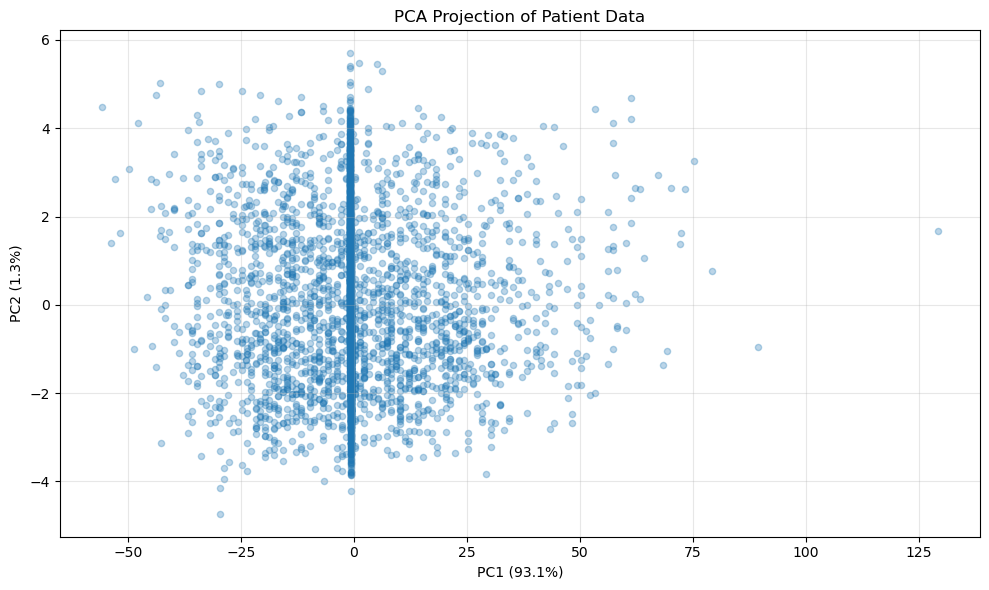

In [7]:
# PCA for linear dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA Variance Explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Visualize PCA
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Projection of Patient Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


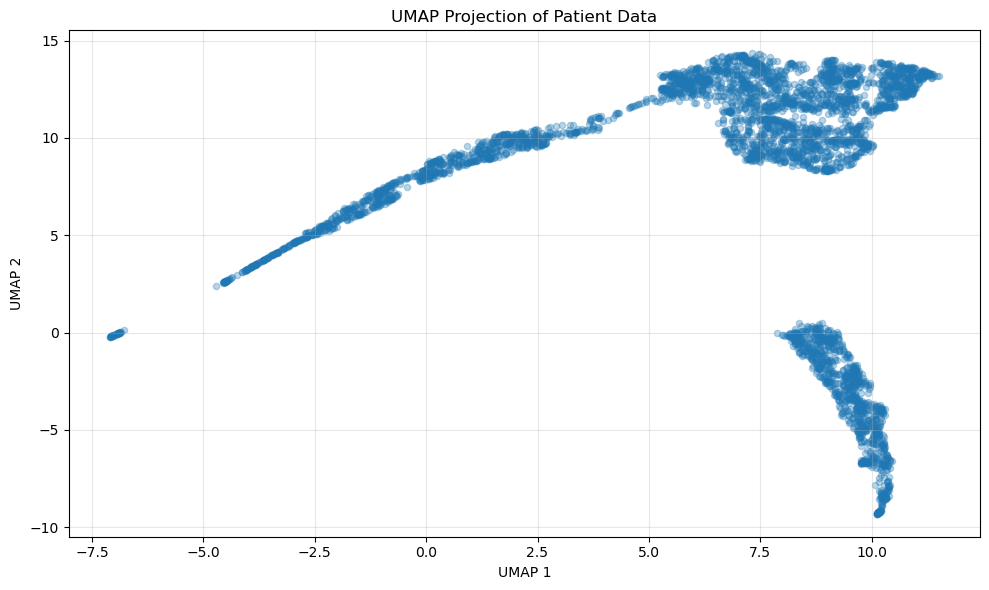

In [8]:
# UMAP for non-linear dimensionality reduction
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    metric='euclidean'
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.3, s=20)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Projection of Patient Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## KMeans

### Optimal Number of Clusters

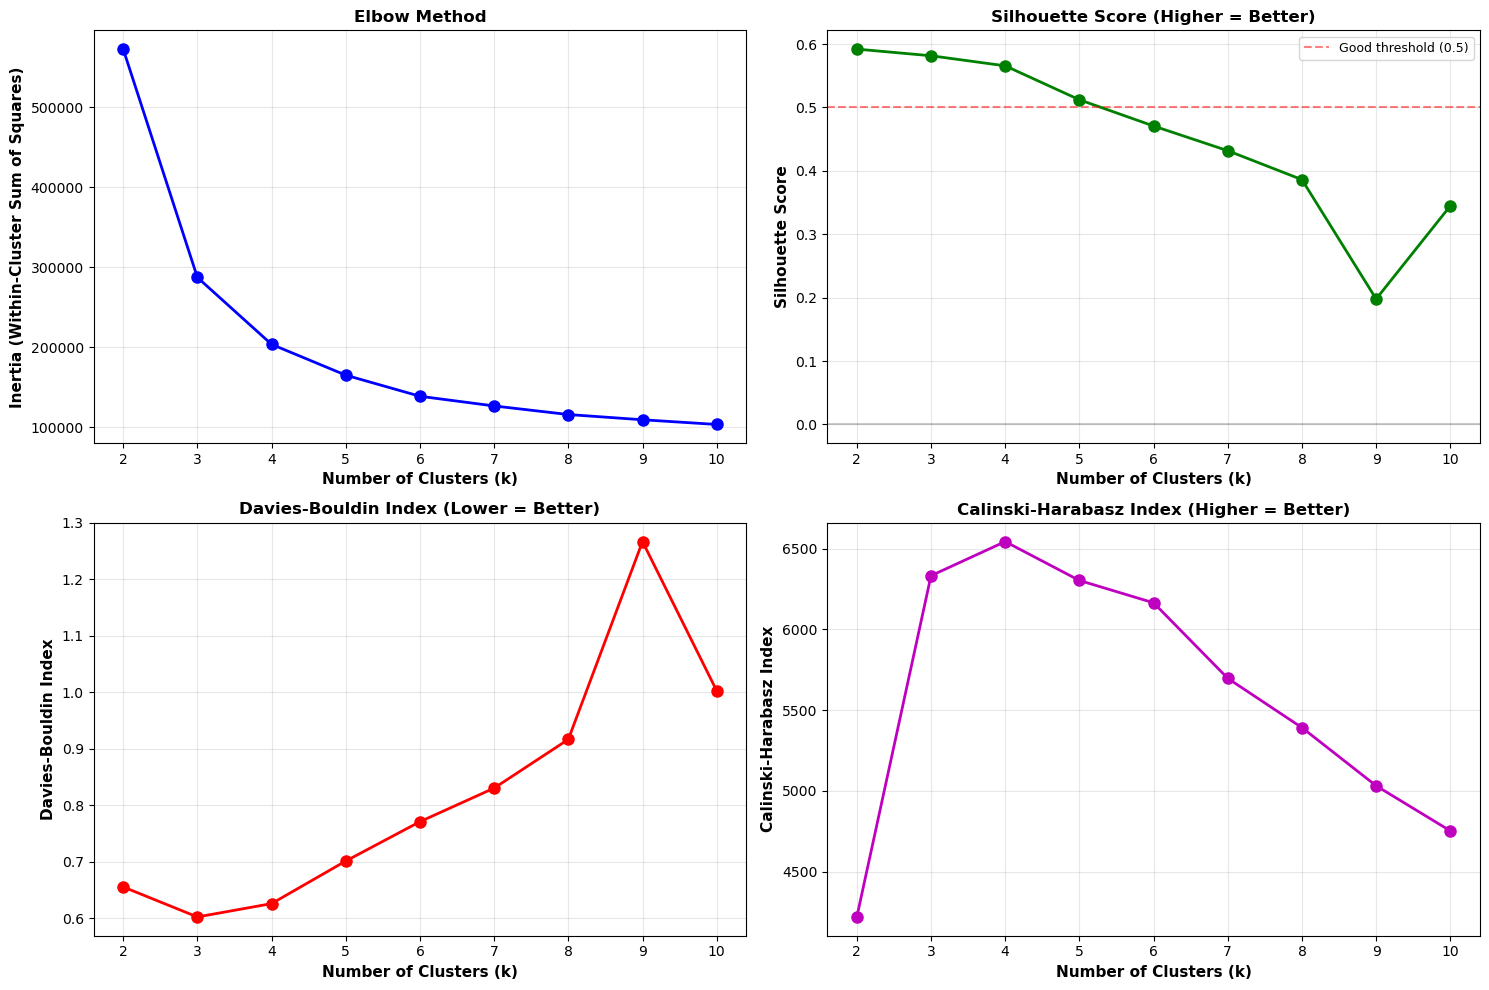

In [9]:
K_range = range(2, 11)  # Test k from 2 to 10 clusters
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    
    inertia = kmeans.inertia_
    inertias.append(inertia)
    
    
    silhouette = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette)
    
    
    davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)
    davies_bouldin_scores.append(davies_bouldin)
    
    calinski_harabasz = calinski_harabasz_score(X_scaled, cluster_labels)
    calinski_harabasz_scores.append(calinski_harabasz)
    
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Elbow plot
axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(K_range)

# 2. Silhouette score (higher is better)
axes[0, 1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Silhouette Score (Higher = Better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Good threshold (0.5)')
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.2)
axes[0, 1].legend(fontsize=9)
axes[0, 1].set_xticks(K_range)

# 3. Davies-Bouldin index (lower is better)
axes[1, 0].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Davies-Bouldin Index (Lower = Better)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(K_range)

# 4. Calinski-Harabasz index (higher is better)
axes[1, 1].plot(K_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Calinski-Harabasz Index', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Calinski-Harabasz Index (Higher = Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(K_range)

plt.tight_layout()
plt.show()

### Characterization

In [10]:
# Perform KMeans clustering with optimal k
optimal_k = 3  

print(f"Performing KMeans clustering with k={optimal_k}...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add labels to dataframe
df['kmeans_cluster'] = kmeans_labels

# Cluster statistics
print(f"\nCluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

# Clustering metrics
sil_score = silhouette_score(X_scaled, kmeans_labels)
db_score = davies_bouldin_score(X_scaled, kmeans_labels)
ch_score = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"\nClustering Quality Metrics:")
print(f"  Silhouette Score: {sil_score:.3f}")
print(f"  Davies-Bouldin Index: {db_score:.3f}")
print(f"  Calinski-Harabasz Index: {ch_score:.1f}")

Performing KMeans clustering with k=3...

Cluster distribution:
kmeans_cluster
0     707
1     546
2    3025
Name: count, dtype: int64

Clustering Quality Metrics:
  Silhouette Score: 0.582
  Davies-Bouldin Index: 0.602
  Calinski-Harabasz Index: 6332.0


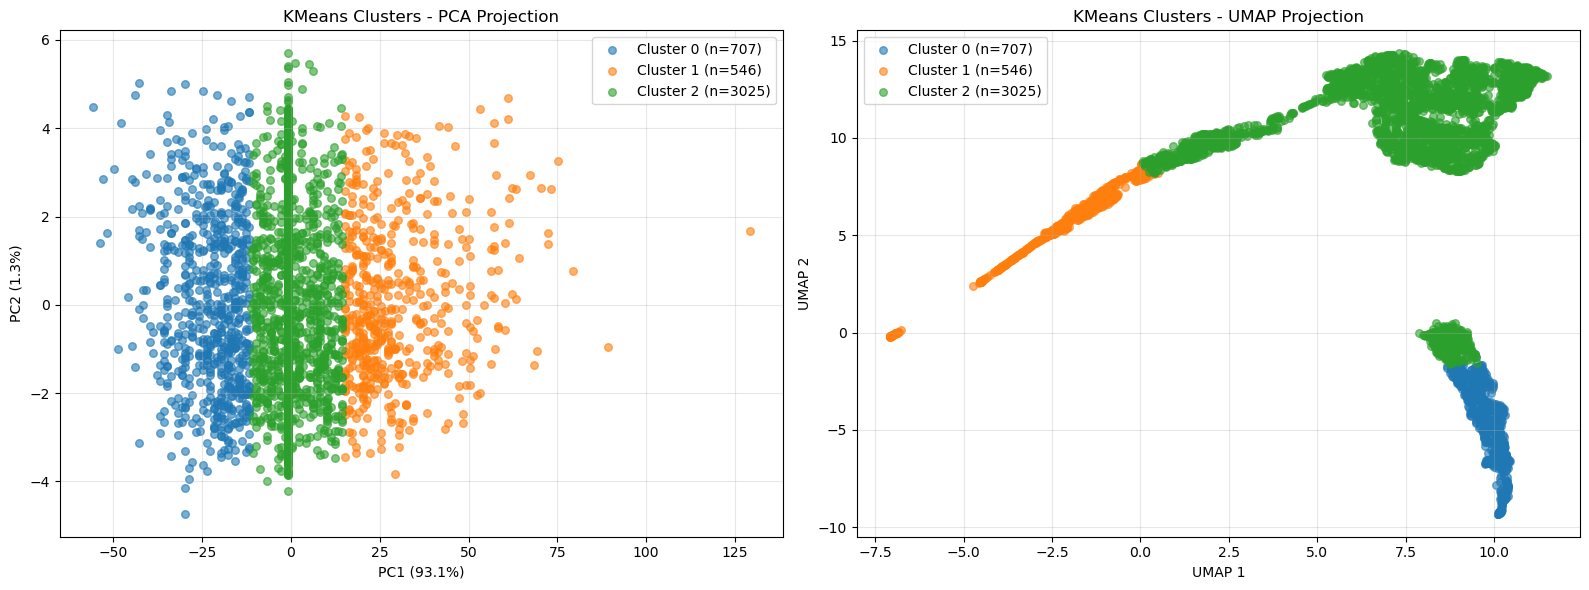

In [11]:
# Visualize clusters in PCA space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA visualization
for i in range(optimal_k):
    mask = kmeans_labels == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.6, s=30)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('KMeans Clusters - PCA Projection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# UMAP visualization
for i in range(optimal_k):
    mask = kmeans_labels == i
    ax2.scatter(X_umap[mask, 0], X_umap[mask, 1],
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.6, s=30)

ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title('KMeans Clusters - UMAP Projection')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Clinical Interpretation of Clusters

### Feature Comparison Across Clusters

In [ ]:
# Helper function to create clinical summaries
def create_cluster_summary(df, cluster_col='kmeans_cluster', feature_groups=feature_groups):
    """
    Create detailed clinical summary for each cluster.
    """
    summaries = {}
    
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster_id]
        n_patients = len(cluster_data)
        
        summary = {
            'n_patients': n_patients,
            'percentage': (n_patients / len(df)) * 100,
            'features': {}
        }
        
        # Compute statistics for each feature group
        for group_name, features in feature_groups.items():
            available_features = [f for f in features if f in df.columns]
            if available_features:
                group_stats = cluster_data[available_features].describe().loc[['mean', '50%', 'std']]
                summary['features'][group_name] = group_stats.T
        
        summaries[f'Cluster {cluster_id}'] = summary
    
    return summaries

# Create summaries
cluster_summaries = create_cluster_summary(df)

# Display summaries
for cluster_name, summary in cluster_summaries.items():
    print("="*80)
    print(f"{cluster_name}")
    print("="*80)
    print(f"Patients: {summary['n_patients']} ({summary['percentage']:.1f}%)")
    print("\n")
    
    for group_name, stats in summary['features'].items():
        print(f"\n{group_name}")
        print("-"*80)
        display(stats)
    print("\n")

In [ ]:
cluster_means = df.groupby('kmeans_cluster').mean()

# Normalize for better visualization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cluster_means_normalized = pd.DataFrame(
    scaler.fit_transform(cluster_means.T).T,
    columns=cluster_means.columns,
    index=cluster_means.index
)

plt.figure(figsize=(16, 8))
sns.heatmap(cluster_means_normalized.T, cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Normalized Value'}, 
            linewidths=0.5, linecolor='gray')
plt.title('Feature Profile by Cluster (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Statistical Testing: Feature Differences Between Clusters

In [ ]:
# Kruskal-Wallis test for each feature
# (non-parametric test for differences across multiple groups)

kruskal_results = []

for feature in features_for_clustering.columns:
    groups = [df[df['kmeans_cluster'] == i][feature].dropna() 
              for i in range(optimal_k)]
    
    # Only test if all groups have data
    if all(len(g) > 0 for g in groups):
        stat, p_value = kruskal(*groups)
        kruskal_results.append({
            'Feature': feature,
            'H-statistic': stat,
            'p-value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })

kruskal_df = pd.DataFrame(kruskal_results).sort_values('p-value')

print("\nFeatures with Significant Differences Across Clusters (p < 0.05):")
print("="*80)
display(kruskal_df[kruskal_df['Significant'] == 'Yes'].head(15))

print(f"\nTotal significant features: {(kruskal_df['Significant'] == 'Yes').sum()}/{len(features_for_clustering.columns)}")

### Box Plots: Key Clinical Features by Cluster

In [ ]:
# Select most discriminative features for visualization
top_features = kruskal_df[kruskal_df['Significant'] == 'Yes']['Feature'].tolist()

top_features = [f for f in top_features if f in df.columns]

n_features = len(top_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 16))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    df.boxplot(column=feature, by='kmeans_cluster', ax=axes[idx])
    axes[idx].set_title(f'{feature}')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Value')
    plt.sca(axes[idx])
    plt.xticks(rotation=0)

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('')
fig.suptitle('Top Discriminative Features by Cluster', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

We can redo clustering with significant features to see if we obtain a clean separation of the clusters.

In [ ]:
X_significant = df[top_features]
X_sig_scaled = RobustScaler().fit_transform(X_significant)


In [ ]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_sig_scaled)
    sil = silhouette_score(X_sig_scaled, labels)
    print(f"k={k}: Silhouette={sil:.3f}")

In [ ]:
kmeans_sig = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
kmeans_labels_sig = kmeans.fit_predict(X_sig_scaled)

df['kmeans_cluster_sig'] = kmeans_labels_sig

In [ ]:
X_pca_sig = pca.fit_transform(X_sig_scaled)
X_umap_sig = reducer.fit_transform(X_sig_scaled)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA visualization
for i in range(optimal_k):
    mask = kmeans_labels_sig == i
    ax1.scatter(X_pca_sig[mask, 0], X_pca_sig[mask, 1], 
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.6, s=30)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('KMeans Clusters with significant features - PCA Projection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# UMAP visualization
for i in range(optimal_k):
    mask = kmeans_labels_sig == i
    ax2.scatter(X_umap_sig[mask, 0], X_umap_sig[mask, 1],
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.6, s=30)

ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title('KMeans Clusters with significant features - UMAP Projection')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Clinical interpretation of k-means clustering


**Cluster 1 (n=626) - Critically Ill Hypertensive Patients**

This cluster is clearly distinguished by:

- Systolic BP = 154 mmHg (highest among all clusters, severe hypertension)
- Age = 71.5 years (oldest)
- Lower Testing Intensity and Disease Burden despite age
- Lower Total Tests (9.9)

**Interpretation:** Elderly patients with severe hypertension but paradoxically with less clinical complexity. They may be hospitalized for management of primary hypertension or patients with stable chronic conditions.
​

**Cluster 0 (n=3404) - Standard/Normotensive Patients**
Characteristics:
- Systolic BP = 128 mmHg (normal values/prehypertension)
- Age = 70.3 years
- Total Tests = 11.0 (moderate)
- Disease Burden, Testing Intensity, and Procedure Complexity: Moderate
- Lower K Min and K Max

**Interpretation:** Main cluster with a standard profile, representing the majority of patients with routine medical conditions and normal vital signs.
​

**Cluster 2 (n=731) - Hypotensive/Highly Complex Patients**
Distinctive Profile:

- Systolic BP = 108 mmHg (lowest, relative hypotension)
- Testing Intensity and Disease Burden highest among all clusters
- Highest Total Tests (11.6)
- Highest Kmax (4.6) - possible electrolyte imbalance
- Age = 70.2 years (similar to others)

**Interpretation:** Critically ill patients with low blood pressure and maximum clinical complexity. They may be septic, in shock, or with multiple organ failure requiring intensive monitoring.

## Hierarchical Clustering

Computing hierarchical clustering on 1000 samples...


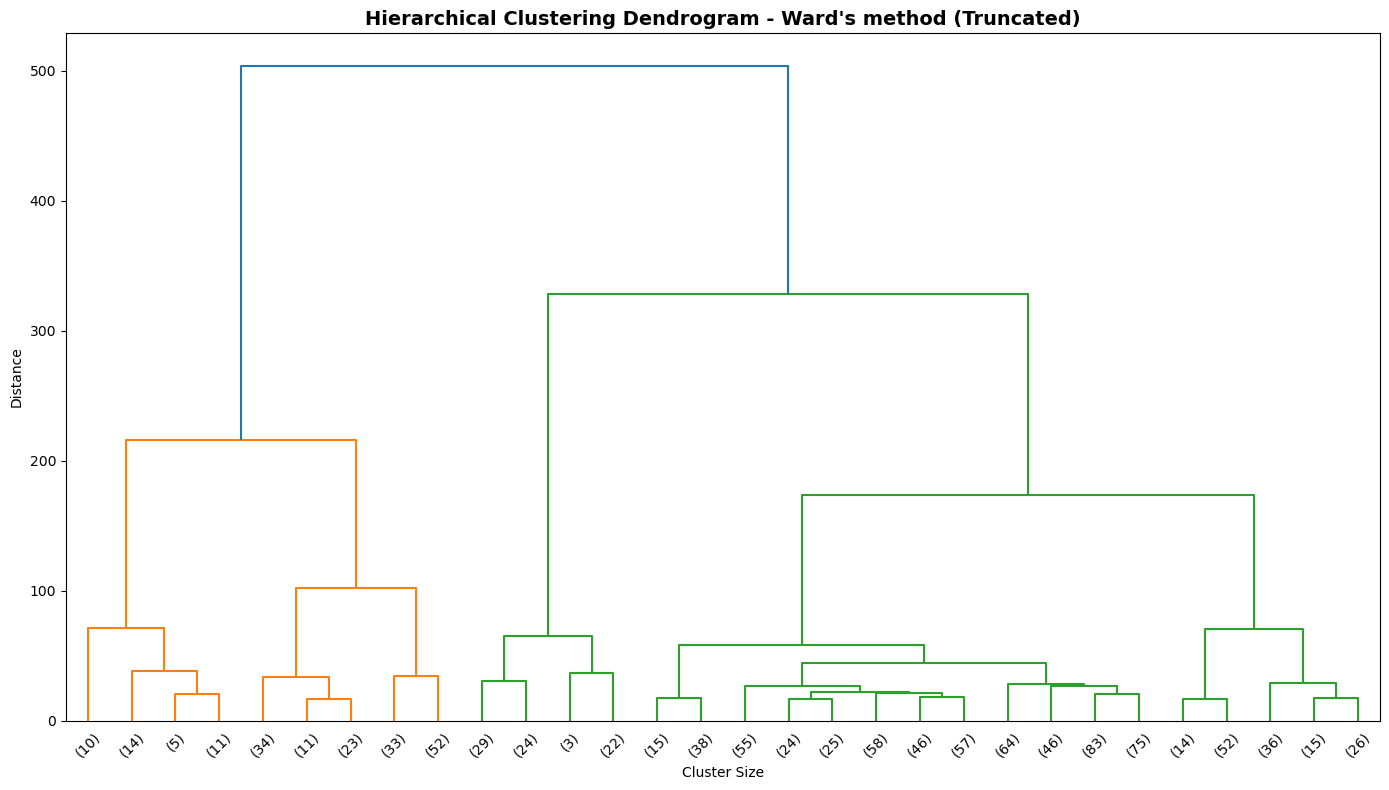

In [12]:
# Dendrogram for hierarchical clustering
# Use a sample for computational efficiency
sample_size = min(1000, len(df))
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

print(f"Computing hierarchical clustering on {sample_size} samples...")

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_font_size=10
)
plt.title('Hierarchical Clustering Dendrogram - Ward\'s method (Truncated)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [13]:
# Perform hierarchical clustering on full dataset
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

df['hierarchical_cluster'] = hierarchical_labels

print(f"\nHierarchical Clustering Results:")
print(df['hierarchical_cluster'].value_counts().sort_index())

# Compare with KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(kmeans_labels, hierarchical_labels)
nmi = normalized_mutual_info_score(kmeans_labels, hierarchical_labels)

print(f"\nAgreement between KMeans and Hierarchical:")
print(f"  Adjusted Rand Index: {ari:.3f}")
print(f"  Normalized Mutual Information: {nmi:.3f}")


Hierarchical Clustering Results:
hierarchical_cluster
0    3330
1     447
2     501
Name: count, dtype: int64

Agreement between KMeans and Hierarchical:
  Adjusted Rand Index: 0.756
  Normalized Mutual Information: 0.702


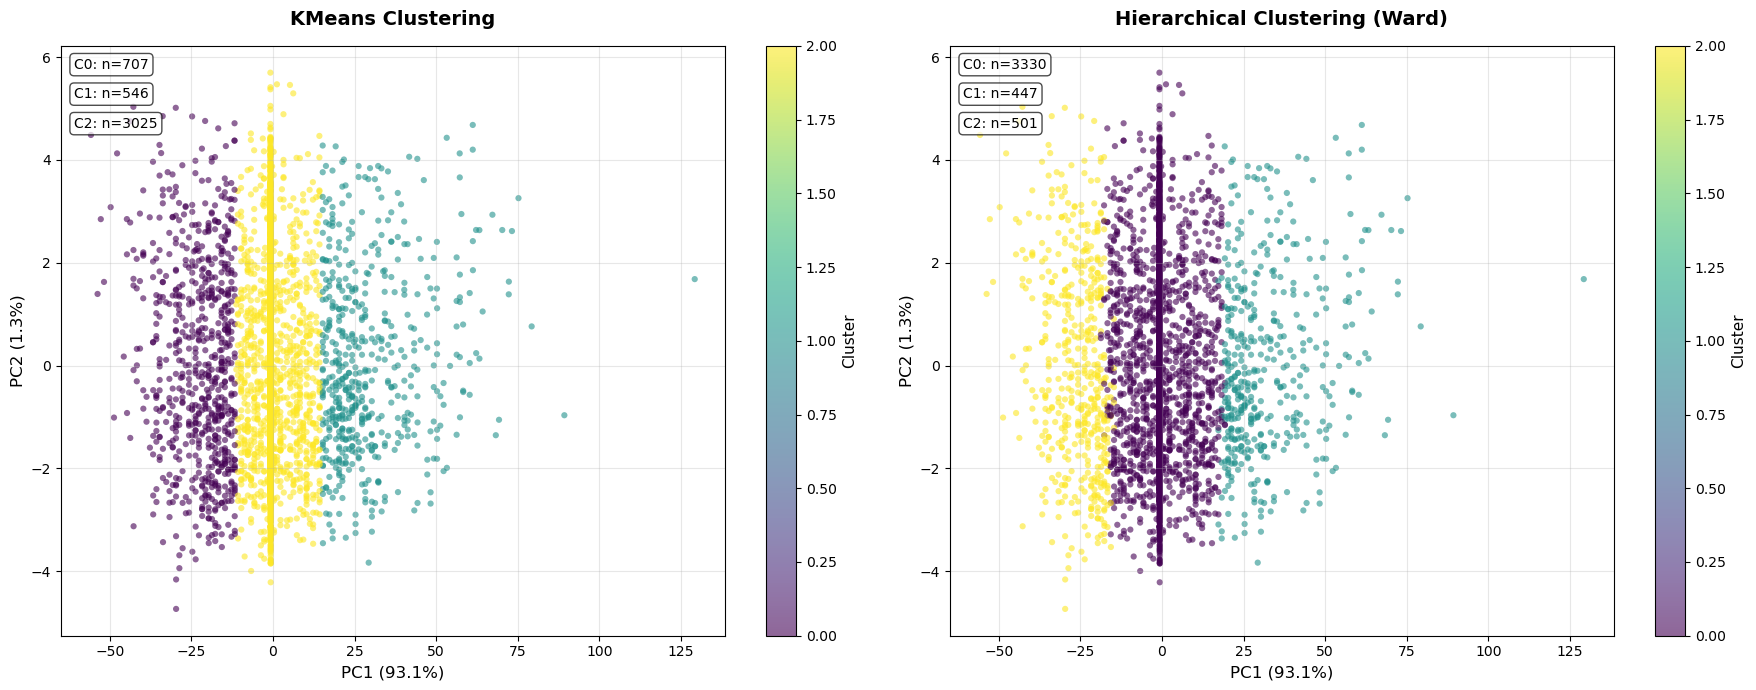

/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


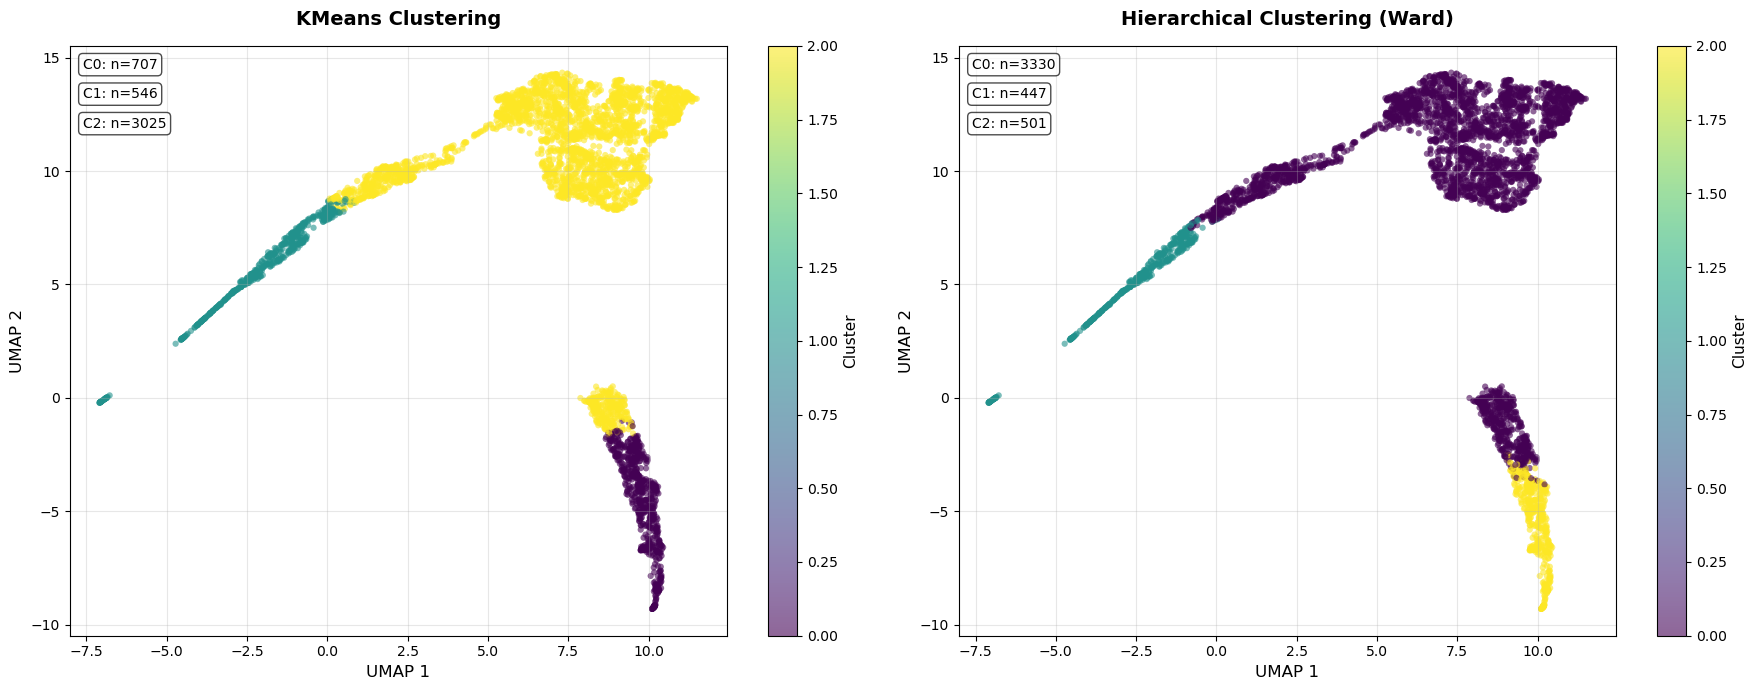

In [14]:
def plot_kmeans_vs_hierarchical(df, X_scaled, method='PCA'):
    """
    Compare KMeans and Hierarchical clustering side by side.
    """
    from sklearn.decomposition import PCA
    import umap
    
    # Dimensionality reduction
    if method == 'PCA':
        reducer = PCA(n_components=2, random_state=42)
        X_reduced = reducer.fit_transform(X_scaled)
        var_explained = reducer.explained_variance_ratio_
        xlabel = f'PC1 ({var_explained[0]*100:.1f}%)'
        ylabel = f'PC2 ({var_explained[1]*100:.1f}%)'
    else:  # UMAP
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
        X_reduced = reducer.fit_transform(X_scaled)
        xlabel = 'UMAP 1'
        ylabel = 'UMAP 2'
    
    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # KMeans plot
    scatter1 = ax1.scatter(X_reduced[:, 0], X_reduced[:, 1], 
                          c=df['kmeans_cluster'], cmap='viridis', 
                          alpha=0.6, s=20, edgecolors='none')
    ax1.set_title('KMeans Clustering', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel(xlabel, fontsize=12)
    ax1.set_ylabel(ylabel, fontsize=12)
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('Cluster', fontsize=11)
    ax1.grid(alpha=0.3)
    
    # Add cluster counts
    for cluster_id in sorted(df['kmeans_cluster'].unique()):
        count = (df['kmeans_cluster'] == cluster_id).sum()
        ax1.text(0.02, 0.98 - cluster_id*0.05, f'C{cluster_id}: n={count}',
                transform=ax1.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Hierarchical plot
    scatter2 = ax2.scatter(X_reduced[:, 0], X_reduced[:, 1], 
                          c=df['hierarchical_cluster'], cmap='viridis', 
                          alpha=0.6, s=20, edgecolors='none')
    ax2.set_title('Hierarchical Clustering (Ward)', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel(ylabel, fontsize=12)
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Cluster', fontsize=11)
    ax2.grid(alpha=0.3)
    
    # Add cluster counts
    for cluster_id in sorted(df['hierarchical_cluster'].unique()):
        count = (df['hierarchical_cluster'] == cluster_id).sum()
        ax2.text(0.02, 0.98 - cluster_id*0.05, f'C{cluster_id}: n={count}',
                transform=ax2.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_kmeans_vs_hierarchical(df, X_scaled, method='PCA')
plot_kmeans_vs_hierarchical(df, X_scaled, method='UMAP')

## DBSCAN: Density-Based Clustering

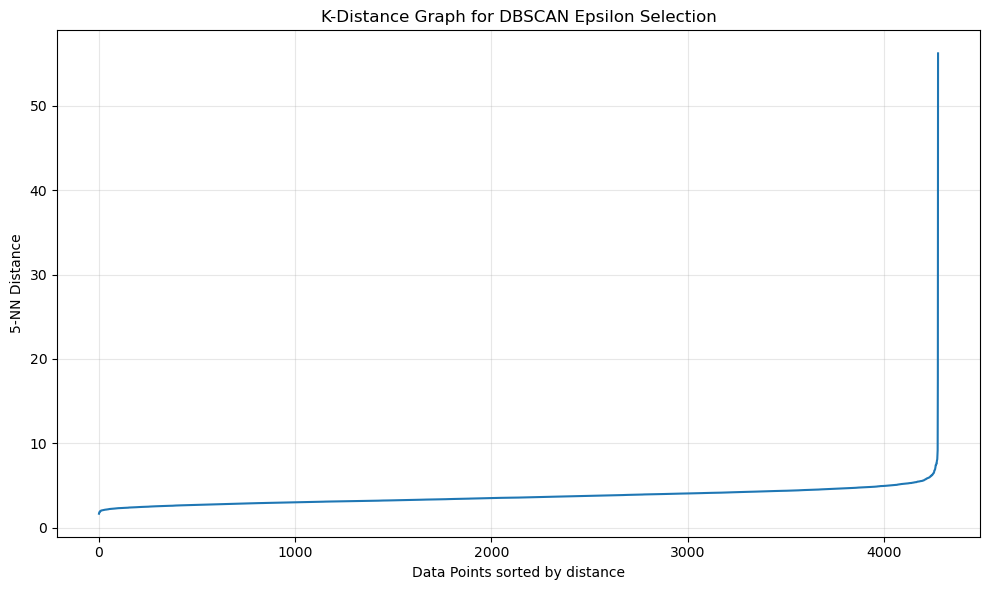


Suggested epsilon (90th percentile): 4.708


In [15]:
# DBSCAN parameter tuning
from sklearn.neighbors import NearestNeighbors

# K-distance graph to find optimal eps
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort and plot
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel(f'{k}-NN Distance')
plt.xlabel('Data Points sorted by distance')
plt.title('K-Distance Graph for DBSCAN Epsilon Selection')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Suggest epsilon (look for "elbow" in the plot)
suggested_eps = np.percentile(distances, 90)
print(f"\nSuggested epsilon (90th percentile): {suggested_eps:.3f}")

In [16]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd


def dbscan_grid_search(X_scaled, eps_range=None, min_samples_range=None,
                       max_noise_pct=15, min_silhouette=0.3):
    """
    Perform grid search for DBSCAN parameters optimizing silhouette score.
    
    Parameters:
    -----------
    X_scaled : array-like
        Scaled feature matrix
    eps_range : list
        Range of eps values to test
    min_samples_range : list
        Range of min_samples values to test
    max_noise_pct : float
        Maximum acceptable percentage of noise points
    min_silhouette : float
        Minimum acceptable silhouette score
    
    Returns:
    --------
    best_params_silhouette : dict
        Best parameters that maximize silhouette score
    best_params_balanced : dict
        Best parameters that balance silhouette and low noise
    results_df : DataFrame
        All results from grid search
    """
    results = []
    
    for eps in eps_range:
        for min_samples in min_samples_range:
            # Fit DBSCAN
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_scaled)
            
            # Calculate basic metrics
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_pct = (n_noise / len(labels)) * 100
            
            # Calculate silhouette score
            if n_clusters > 1 and n_noise < len(labels):
                mask = labels != -1
                if mask.sum() > 1:
                    try:
                        sil_score = silhouette_score(X_scaled[mask], labels[mask])
                    except:
                        sil_score = -1
                else:
                    sil_score = -1
            else:
                sil_score = -1
            
            # Store results
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': noise_pct,
                'silhouette': sil_score
            })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Filter valid results
    valid_results = results_df[
        (results_df['n_clusters'] >= 2) &  
        (results_df['noise_pct'] <= max_noise_pct) &  
        (results_df['silhouette'] >= min_silhouette)  
    ]
    
    # Relaxed constraints if no valid results
    if len(valid_results) == 0:
        print("Warning: No results met strict criteria. Relaxing constraints...")
        valid_results = results_df[
            (results_df['n_clusters'] >= 2) &
            (results_df['noise_pct'] <= max_noise_pct * 1.5)
        ]
    
    best_params_silhouette = None
    best_params_balanced = None
    
    if len(valid_results) > 0:
        # Best params by SILHOUETTE only (maximize silhouette)
        best_idx_sil = valid_results['silhouette'].idxmax()
        best_params_silhouette = valid_results.loc[best_idx_sil].to_dict()
        
        # Best params by BALANCED score (silhouette with penalty for noise)
        valid_results['balanced_score'] = (
            valid_results['silhouette'] - 
            0.2 * (valid_results['noise_pct'] / 100)
        )
        best_idx_balanced = valid_results['balanced_score'].idxmax()
        best_params_balanced = valid_results.loc[best_idx_balanced].to_dict()
       
    # Debug: vediamo cosa sta succedendo
    print("\n" + "="*70)
    print("DIAGNOSTIC INFO:")
    print(f"Total configurations tested: {len(results_df)}")
    print(f"Configurations with >= 2 clusters: {len(results_df[results_df['n_clusters'] >= 2])}")
    print(f"Configurations with noise <= {max_noise_pct}%: {len(results_df[results_df['noise_pct'] <= max_noise_pct])}")
    print(f"Configurations with silhouette >= {min_silhouette}: {len(results_df[results_df['silhouette'] >= min_silhouette])}")
    print(f"Valid configurations (meeting all criteria): {len(valid_results)}")

    return best_params_silhouette, best_params_balanced, results_df


# Define parameter ranges
eps_range = np.arange(4.0, 6.0, 0.1)  
min_samples_range = range(5, 21, 2)  

# Run grid search
best_sil, best_bal, results_df = dbscan_grid_search(
    X_scaled, 
    eps_range=eps_range, 
    min_samples_range=min_samples_range,
    max_noise_pct=25,  
    min_silhouette=0.1  
)

if len(results_df) > 0:
    print("\nBest values found (regardless of constraints):")
    print(f"  Max silhouette: {results_df['silhouette'].max():.3f}")
    print(f"  Min noise_pct: {results_df['noise_pct'].min():.2f}%")
    print(f"  Max n_clusters: {results_df['n_clusters'].max()}")
    
    # Mostra le top 5 configurazioni per silhouette
    print("\nTop 5 configurations by silhouette score:")
    top5 = results_df.nlargest(5, 'silhouette')[['eps', 'min_samples', 'n_clusters', 'noise_pct', 'silhouette']]
    print(top5.to_string(index=False))
print("="*70 + "\n")



# Initialize fallback values
best_eps_sil = 2.208
best_min_samples_sil = 10
best_eps_balanced = 2.208
best_min_samples_balanced = 10

print("="*70)
print("BEST PARAMETERS BY SILHOUETTE SCORE:")
if best_sil is not None:
    print(f"  eps: {best_sil['eps']:.3f}")
    print(f"  min_samples: {int(best_sil['min_samples'])}")
    print(f"  silhouette: {best_sil['silhouette']:.3f}")
    print(f"  n_clusters: {int(best_sil['n_clusters'])}")
    print(f"  noise_pct: {best_sil['noise_pct']:.2f}%")
    best_eps_sil = best_sil['eps']
    best_min_samples_sil = int(best_sil['min_samples'])
else:
    print("  No valid configuration found - using fallback values")

print("\n" + "="*70)
print("BEST PARAMETERS BY BALANCED SCORE (Silhouette - Noise Penalty):")
if best_bal is not None:
    print(f"  eps: {best_bal['eps']:.3f}")
    print(f"  min_samples: {int(best_bal['min_samples'])}")
    print(f"  silhouette: {best_bal['silhouette']:.3f}")
    print(f"  balanced_score: {best_bal['balanced_score']:.3f}")
    print(f"  n_clusters: {int(best_bal['n_clusters'])}")
    print(f"  noise_pct: {best_bal['noise_pct']:.2f}%")
    best_eps_balanced = best_bal['eps']
    best_min_samples_balanced = int(best_bal['min_samples'])
else:
    print("  No valid configuration found - using fallback values")

print("="*70)

# Choose which parameters to use
# Option 1: Maximum silhouette (might have more noise)
final_eps = best_eps_sil
final_min_samples = best_min_samples_sil

# Option 2: Balanced approach (recommended - good silhouette with less noise)
# final_eps = best_eps_balanced
# final_min_samples = best_min_samples_balanced

print(f"\nFinal parameters: eps={final_eps:.3f}, min_samples={final_min_samples}")



DIAGNOSTIC INFO:
Total configurations tested: 160
Configurations with >= 2 clusters: 86
Configurations with noise <= 25%: 148
Configurations with silhouette >= 0.1: 82
Valid configurations (meeting all criteria): 71

Best values found (regardless of constraints):
  Max silhouette: 0.703
  Min noise_pct: 0.58%
  Max n_clusters: 11

Top 5 configurations by silhouette score:
 eps  min_samples  n_clusters  noise_pct  silhouette
 5.3            5           2   1.379149    0.702646
 5.0            9           2   3.155680    0.692862
 5.1            9           2   2.524544    0.687821
 5.1            7           2   2.057036    0.687609
 5.2           11           2   2.337541    0.685754

BEST PARAMETERS BY SILHOUETTE SCORE:
  eps: 5.300
  min_samples: 5
  silhouette: 0.703
  n_clusters: 2
  noise_pct: 1.38%

BEST PARAMETERS BY BALANCED SCORE (Silhouette - Noise Penalty):
  eps: 5.300
  min_samples: 5
  silhouette: 0.703
  balanced_score: 0.700
  n_clusters: 2
  noise_pct: 1.38%

Final pa

/tmp/ipykernel_5596/3127009156.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_results['balanced_score'] = (


/tmp/ipykernel_5596/2647385389.py:205: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


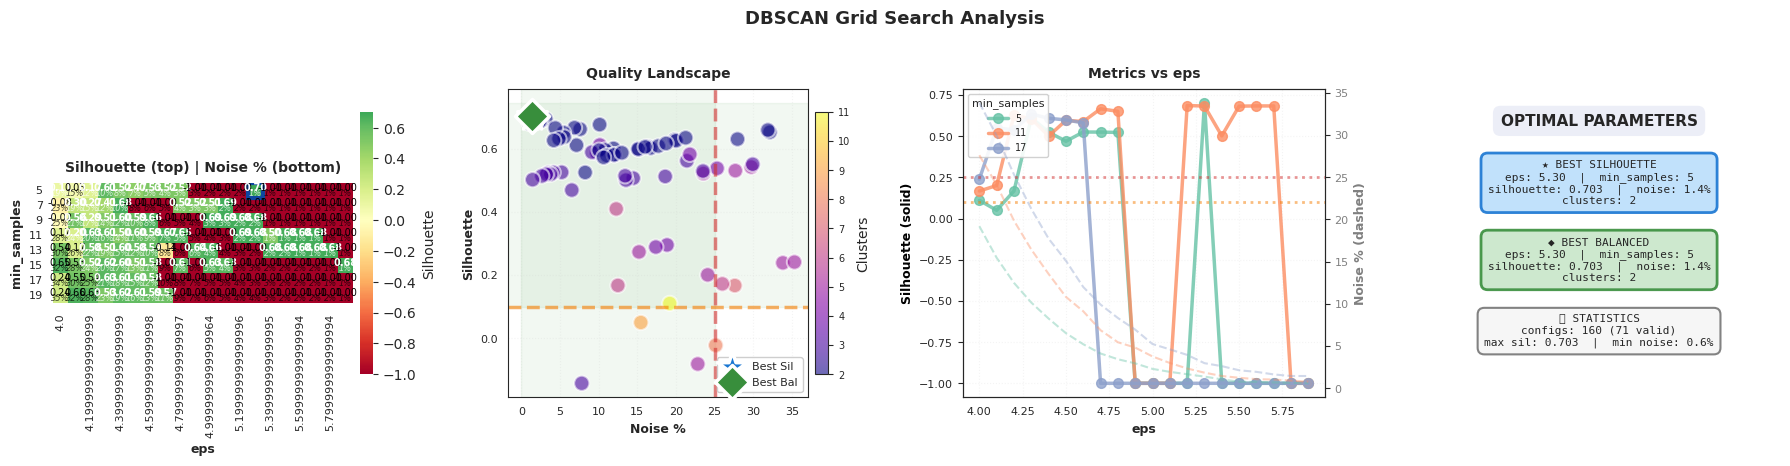

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_dbscan_grid_search_results(results_df, best_sil, best_bal, 
                                     max_noise_pct=25, min_silhouette=0.1):
    """
    Ultra-compact visualization of DBSCAN grid search results.
    """
    
    sns.set_style("white")
    
    # Single row layout: 4 panels
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.patch.set_facecolor('white')
    
    colors = sns.color_palette("Set2", 8)
    
    # === Panel 1: Combined Heatmap (Silhouette + Noise overlay) ===
    ax1 = axes[0]
    pivot_sil = results_df.pivot_table(
        values='silhouette', index='min_samples', columns='eps', aggfunc='mean'
    )
    
    # Heatmap base
    sns.heatmap(pivot_sil, annot=False, cmap='RdYlGn', center=0, ax=ax1,
                cbar_kws={'label': 'Silhouette', 'shrink': 0.85, 'pad': 0.02},
                linewidths=0, square=True)
    
    # Overlay noise percentage as text
    pivot_noise = results_df.pivot_table(
        values='noise_pct', index='min_samples', columns='eps', aggfunc='mean'
    )
    for i, ms in enumerate(pivot_sil.index):
        for j, eps in enumerate(pivot_sil.columns):
            sil_val = pivot_sil.loc[ms, eps]
            noise_val = pivot_noise.loc[ms, eps]
            
            # Color-coded text based on quality
            if sil_val > min_silhouette and noise_val < max_noise_pct:
                color = 'white'
                weight = 'bold'
            else:
                color = 'black'
                weight = 'normal'
            
            ax1.text(j + 0.5, i + 0.3, f'{sil_val:.2f}',
                    ha='center', va='center', fontsize=7, 
                    color=color, weight=weight)
            ax1.text(j + 0.5, i + 0.7, f'{noise_val:.0f}%',
                    ha='center', va='center', fontsize=6, 
                    color=color, alpha=0.7, style='italic')
    
    # Mark best
    if best_sil is not None:
        eps_idx = list(pivot_sil.columns).index(best_sil['eps'])
        ms_idx = list(pivot_sil.index).index(best_sil['min_samples'])
        ax1.add_patch(plt.Rectangle((eps_idx, ms_idx), 1, 1, 
                                     fill=False, edgecolor='#0D47A1', lw=3))
    
    ax1.set_title('Silhouette (top) | Noise % (bottom)', 
                  fontsize=10, fontweight='bold', pad=8)
    ax1.set_xlabel('eps', fontsize=9, fontweight='bold')
    ax1.set_ylabel('min_samples', fontsize=9, fontweight='bold')
    ax1.tick_params(labelsize=8)
    
    # === Panel 2: Quality Trade-off Scatter ===
    ax2 = axes[1]
    
    valid_mask = (results_df['silhouette'] > -1) & (results_df['n_clusters'] > 0)
    plot_data = results_df[valid_mask]
    
    scatter = ax2.scatter(plot_data['noise_pct'], plot_data['silhouette'], 
                         c=plot_data['n_clusters'], cmap='plasma', 
                         s=120, alpha=0.6, edgecolors='white', linewidth=1.5)
    
    # Constraints
    ax2.axvline(max_noise_pct, color='#D32F2F', linestyle='--', 
                linewidth=2.5, alpha=0.6, zorder=1)
    ax2.axhline(min_silhouette, color='#F57C00', linestyle='--', 
                linewidth=2.5, alpha=0.6, zorder=1)
    
    # Shade valid region
    ax2.axvspan(0, max_noise_pct, alpha=0.05, color='green', zorder=0)
    ax2.axhspan(min_silhouette, ax2.get_ylim()[1], alpha=0.05, color='green', zorder=0)
    
    # Mark best
    if best_sil is not None:
        ax2.scatter(best_sil['noise_pct'], best_sil['silhouette'], 
                   s=500, marker='*', c='#1976D2', edgecolors='white', 
                   linewidth=2.5, label='Best Sil', zorder=10)
    if best_bal is not None:
        ax2.scatter(best_bal['noise_pct'], best_bal['silhouette'], 
                   s=300, marker='D', c='#388E3C', edgecolors='white', 
                   linewidth=2.5, label='Best Bal', zorder=10)
    
    ax2.set_xlabel('Noise %', fontsize=9, fontweight='bold')
    ax2.set_ylabel('Silhouette', fontsize=9, fontweight='bold')
    ax2.set_title('Quality Landscape', fontsize=10, fontweight='bold', pad=8)
    ax2.legend(loc='lower right', fontsize=8, framealpha=0.95)
    ax2.grid(alpha=0.2, linestyle=':')
    ax2.tick_params(labelsize=8)
    
    cbar = plt.colorbar(scatter, ax=ax2, label='Clusters', shrink=0.85, pad=0.02)
    cbar.ax.tick_params(labelsize=7)
    
    # === Panel 3: Dual-axis line plot (Silhouette + Noise) ===
    ax3 = axes[2]
    ax3_twin = ax3.twinx()
    
    # Select representative min_samples values
    ms_values = sorted(results_df['min_samples'].unique())[::3]  # Every 3rd
    
    for idx, ms in enumerate(ms_values):
        subset = results_df[results_df['min_samples'] == ms].sort_values('eps')
        
        # Silhouette on left axis
        ax3.plot(subset['eps'], subset['silhouette'], 
                marker='o', markersize=7, linewidth=2.5, 
                label=f'{ms}', color=colors[idx], alpha=0.8)
        
        # Noise on right axis (dashed)
        ax3_twin.plot(subset['eps'], subset['noise_pct'], 
                     linestyle='--', linewidth=1.5, 
                     color=colors[idx], alpha=0.4)
    
    ax3.axhline(min_silhouette, color='#F57C00', linestyle=':', 
                linewidth=2, alpha=0.5)
    ax3_twin.axhline(max_noise_pct, color='#D32F2F', linestyle=':', 
                     linewidth=2, alpha=0.5)
    
    ax3.set_xlabel('eps', fontsize=9, fontweight='bold')
    ax3.set_ylabel('Silhouette (solid)', fontsize=9, fontweight='bold', color='black')
    ax3_twin.set_ylabel('Noise % (dashed)', fontsize=9, fontweight='bold', color='gray')
    ax3.set_title('Metrics vs eps', fontsize=10, fontweight='bold', pad=8)
    
    ax3.legend(title='min_samples', fontsize=7, title_fontsize=8, 
               loc='upper left', ncol=1, framealpha=0.9)
    ax3.grid(alpha=0.2, linestyle=':')
    ax3.tick_params(labelsize=8)
    ax3_twin.tick_params(labelsize=8, labelcolor='gray')
    
    # === Panel 4: Compact Summary ===
    ax4 = axes[3]
    ax4.axis('off')
    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)
    
    y = 0.92
    
    # Title
    ax4.text(0.5, y, 'OPTIMAL PARAMETERS', ha='center', va='top',
            fontsize=11, fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8EAF6', 
                     edgecolor='none', alpha=0.8))
    y -= 0.15
    
    # Best Silhouette
    if best_sil is not None:
        info_text = (
            f"★ BEST SILHOUETTE\n"
            f"eps: {best_sil['eps']:.2f}  |  min_samples: {int(best_sil['min_samples'])}\n"
            f"silhouette: {best_sil['silhouette']:.3f}  |  noise: {best_sil['noise_pct']:.1f}%\n"
            f"clusters: {int(best_sil['n_clusters'])}"
        )
        ax4.text(0.5, y, info_text, ha='center', va='top',
                fontsize=8, family='monospace',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#BBDEFB', 
                         edgecolor='#1976D2', linewidth=2, alpha=0.9))
        y -= 0.25
    
    # Best Balanced
    if best_bal is not None:
        info_text = (
            f"◆ BEST BALANCED\n"
            f"eps: {best_bal['eps']:.2f}  |  min_samples: {int(best_bal['min_samples'])}\n"
            f"silhouette: {best_bal['silhouette']:.3f}  |  noise: {best_bal['noise_pct']:.1f}%\n"
            f"clusters: {int(best_bal['n_clusters'])}"
        )
        ax4.text(0.5, y, info_text, ha='center', va='top',
                fontsize=8, family='monospace',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#C8E6C9', 
                         edgecolor='#388E3C', linewidth=2, alpha=0.9))
        y -= 0.25
    
    # Stats
    valid_count = len(results_df[
        (results_df['n_clusters'] >= 2) & 
        (results_df['noise_pct'] <= max_noise_pct) & 
        (results_df['silhouette'] >= min_silhouette)
    ])
    
    stats_text = (
        f"📊 STATISTICS\n"
        f"configs: {len(results_df)} ({valid_count} valid)\n"
        f"max sil: {results_df['silhouette'].max():.3f}  |  min noise: {results_df['noise_pct'].min():.1f}%"
    )
    ax4.text(0.5, y, stats_text, ha='center', va='top',
            fontsize=8, family='monospace',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#F5F5F5', 
                     edgecolor='#757575', linewidth=1.5, alpha=0.9))
    
    plt.suptitle('DBSCAN Grid Search Analysis', 
                 fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    return fig


# Usa la funzione
if len(results_df) > 0:
    fig = plot_dbscan_grid_search_results(
        results_df, best_sil, best_bal,
        max_noise_pct=25, min_silhouette=0.1
    )
    plt.show()
else:
    print("No results to plot!")


In [18]:
dbscan = DBSCAN(eps=final_eps, min_samples=final_min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels

# Statistics
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Results:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Number of noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"\nCluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index())

# Calculate final silhouette
if n_clusters > 1 and n_noise < len(df):
    mask = dbscan_labels != -1
    if mask.sum() > 1:
        final_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f"\nFinal Silhouette Score: {final_sil:.3f}")



DBSCAN Results:
  Number of clusters: 2
  Number of noise points: 59 (1.4%)

Cluster distribution:
dbscan_cluster
-1      59
 0    4215
 1       4
Name: count, dtype: int64

Final Silhouette Score: 0.703


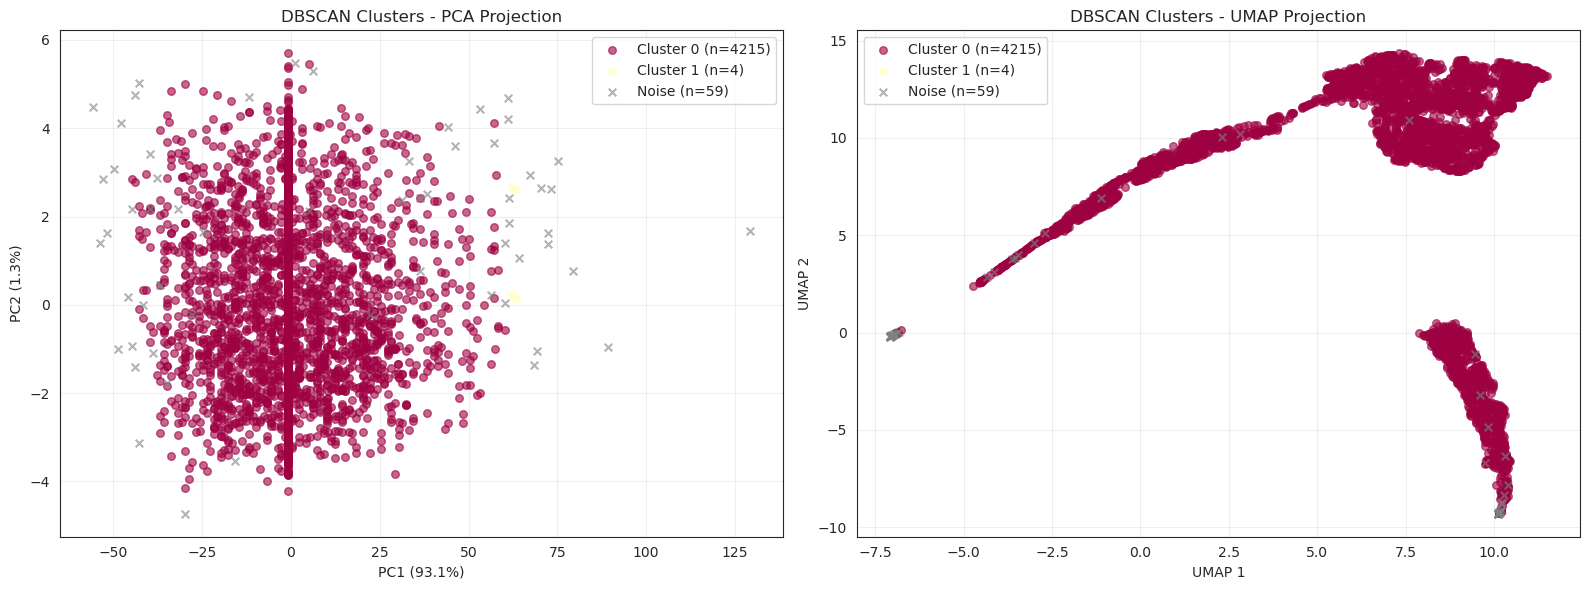

In [19]:
# Visualize DBSCAN clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA
unique_labels = set(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'gray'
        marker = 'x'
        label_str = 'Noise'
    else:
        marker = 'o'
        label_str = f'Cluster {label}'
    
    mask = dbscan_labels == label
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color], marker=marker, label=f'{label_str} (n={mask.sum()})',
               alpha=0.6, s=30)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('DBSCAN Clusters - PCA Projection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# UMAP
for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'gray'
        marker = 'x'
        label_str = 'Noise'
    else:
        marker = 'o'
        label_str = f'Cluster {label}'
    
    mask = dbscan_labels == label
    ax2.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=[color], marker=marker, label=f'{label_str} (n={mask.sum()})',
               alpha=0.6, s=30)

ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title('DBSCAN Clusters - UMAP Projection')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Comparison & Final Selection

In [22]:
# Compare all clustering methods
comparison = pd.DataFrame({
    'Method': ['KMeans', 'Hierarchical', 'DBSCAN'],
    'N_Clusters': [
        len(df['kmeans_cluster'].unique()),
        len(df['hierarchical_cluster'].unique()),
        len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    ],
    'Silhouette': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hierarchical_labels),
        silhouette_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else np.nan
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, hierarchical_labels),
        davies_bouldin_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else np.nan
    ],
    'Calinski-Harabasz': [
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, hierarchical_labels),
        calinski_harabasz_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else np.nan
    ]
})

print("Clustering Method Comparison")
print("="*80)
display(comparison)

print("\n💡 Interpretation:")
print("  - Silhouette Score: Higher is better (>0.5 is good)")
print("  - Davies-Bouldin: Lower is better")
print("  - Calinski-Harabasz: Higher is better")

Clustering Method Comparison


,Method,N_Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,3,0.581502,0.602130,6331.953534
1,Hierarchical,3,0.578207,0.548226,5643.113209
2,DBSCAN,2,0.616782,3.627167,46.465305



💡 Interpretation:
  - Silhouette Score: Higher is better (>0.5 is good)
  - Davies-Bouldin: Lower is better
  - Calinski-Harabasz: Higher is better


KMEANS is the best method for clustering the patients, based on metrics and visual separation of the clusters